In [1]:
from fourth_day import Fourth_Day , config
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import config_icetray 
import logging
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import pickle
import glob

In [3]:
def create_config(config, **kwargs):

    if "rs" in kwargs:
        rs = kwargs["rs"]
    else:
        rs = np.random.randint(0, 10000)
    config['general']['random state seed'] = rs
    config['general']['enable logging'] = False  
    config['general']['debug level'] = logging.DEBUG 
    config['general']['log file handler'] = '/home/clagunas/projects/rpp-nahee/clagunas/fourth_day/run/fd.log'  
    config['general']['config location'] = '/home/clagunas/projects/rpp-nahee/clagunas/fourth_day/run/config.txt' 

    config['scenario']['organism movement'] = False # was false by default
    config['scenario']['population size'] = 10  # The starting population size
    config['scenario']['duration'] = 300 * 1  # Total simulation time in seconds
    config['scenario']['exclusion'] = False  # If an exclusion zone should be used (the detector)
    config['scenario']['injection']['rate'] = 1  #  Injection rate in per second, a distribution is constructed from this value
    config['scenario']['injection']['y range'] = [0., 10.]  # The y-range of injection
    config['scenario']['detector'] = {  # detector specific properties, positions are defined as offsets from the light prop values
        "switch": True,  # If the detector should be modelled
        "type": "POM",  # Detector name, implemented types are given in the config
        "response": True,  # If a detector response should be used
        "acceptance": "Flat",  # Flat acceptance
        "mean detection prob": 1.  # Used for the acceptance calculation
    }

    config['organisms']['emission fraction'] = 0.1  # Amount of energy an organism uses per pulse
    config['organisms']['alpha'] = 1e0  # Proportionality factor for the emission probability
    config['organisms']["minimal shear stress"] = 0.005  # The minimal amount of shear stress needed to emit (generic units)
    config["organisms"]["filter"] = 'depth'  # Method of filtering organisms (here depth)
    config["organisms"]["depth filter"] = 1000.  # Organisms need to exist below this depth
    
    config['water']['model']['name'] = 'custom'  
    config['water']['model']['off set'] = np.array([0., 0.])  
    config['water']['model']['directory'] = "/Parabola_5mm/run_5cm_npy/"  
    config['water']['model']['time step'] = 1.  

    return config

In [4]:
def plot_water_velocity_and_organisms(fd, time_step):
   
    df_step = fd.statistics[time_step]
    
    x = np.arange(0,15,0.01) #0,10
    y = np.arange(5,10,0.01) #5,10
    points = np.asarray( [ [i, j] for i in x for j in y ] )
    res = fd._current.velocities(points, out_nr = 100)

    X, Y = np.meshgrid(x, y, indexing='ij')
    Z = res[-1].reshape(len(x), len(y))

    fig, ax = plt.subplots()

    pc = ax.pcolormesh(X, Y, Z, shading='auto')
    #fig.colorbar(pc, ax=ax)

    ax.scatter(df_step.loc[~df_step['is_emitting'],'pos_x'], 
            df_step.loc[~df_step['is_emitting'], 'pos_y'], 
            c='red', s=5)
    ax.scatter(df_step.loc[df_step['is_emitting'],'pos_x'], 
            df_step.loc[df_step['is_emitting'], 'pos_y'], 
            c='yellow', s=5)

    ax.set_xlim(0, 15)
    ax.set_ylim(5, 10)
    ax.set_aspect('equal', adjustable='box')

    plt.show()  

In [ ]:
def animate_water_velocity_and_organisms(fd, time_steps, interval=200, saveas=None):
    """
    fd           your simulation object
    time_steps   list or range of time indices
    interval     ms between frames
    """
  
    x = np.arange(0, 15, 0.01)   
    y = np.arange(5, 10, 0.01)

    X, Y = np.meshgrid(x, y, indexing='ij')

    fig, ax = plt.subplots(figsize=(6, 4))
    points = np.column_stack([X.ravel(), Y.ravel()])
    res = fd._current.velocities(points, out_nr=time_steps[0])
    Z0 = res[-1].reshape(len(x), len(y))

    pc = ax.pcolormesh(X, Y, Z0, shading='auto')

    # placeholders
    scat_emit = ax.scatter([], [], c='yellow', s=5)
    scat_no_emit = ax.scatter([], [], c='red', s=5)

    ax.set_xlim(0, 15)
    ax.set_ylim(5, 10)
    ax.set_aspect('equal', adjustable='box')

    def update(frame_idx):
        
        t = time_steps[frame_idx]

        points = np.column_stack([X.ravel(), Y.ravel()])
        res = fd._current.velocities(points, out_nr=t)
        Z = res[-1].reshape(X.shape)

        pc.set_array(Z.ravel())

        df_step = fd.statistics[t]

        scat_emit.set_offsets(
            df_step.loc[df_step['is_emitting'], ['pos_x', 'pos_y']].values
        )
        scat_no_emit.set_offsets(
            df_step.loc[~df_step['is_emitting'], ['pos_x', 'pos_y']].values
        )

        ax.set_title(f"Time step: {t}")
        return pc, scat_emit, scat_no_emit

    anim = FuncAnimation(
        fig,
        update,
        frames=len(time_steps),
        interval=interval,
        blit=False
    )

    plt.show()

    if saveas:
        anim.save(saveas, writer="imagemagick")
        
    return anim


In [6]:
baseconfig = create_config(config_icetray._baseconfig, rs = 42)
fd = Fourth_Day(userconfig=baseconfig)

In [7]:
fd.sim()

In [20]:
fd._current._save_string_vel

PosixPath('/project/6008051/clagunas/fourth_day/fourth_day/data/current/Parabola_5mm/run_10cm_npy/npy_values_wind')

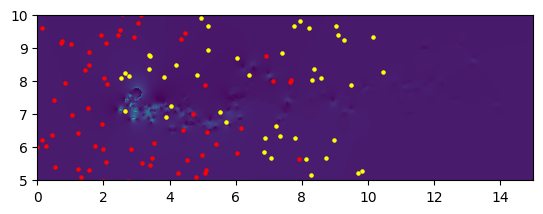

In [13]:
plot_water_velocity_and_organisms(fd, time_step=200)

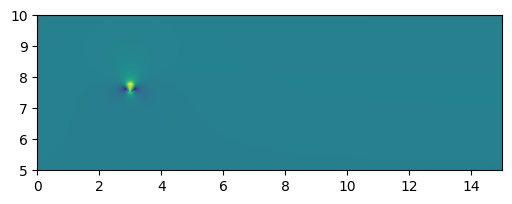

In [11]:
time_steps = range(0,100) 
anim = animate_water_velocity_and_organisms(fd, time_steps, interval=150, saveas='animation_movement_false_42_5cms.gif')
HTML(anim.to_jshtml())

In [10]:
baseconfig = create_config(config_icetray._baseconfig, rs = 42)
fd_2 = Fourth_Day(userconfig=baseconfig)
fd_2.sim()

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 0.          0.00371806  0.00686039 -0.000485    0.          0.
  0.00733484  0.0009852   0.         -0.00036929  0.        ]
[0.         0.00247078 0.00163898 0.00293181 0.         0.
 0.0085786  0.00378633 0.         0.00503128 0.00228816 0.
 0.        ]
[ 0.          0.00594923  0.0027174  -0.00144589  0.          0.
  0.00021514  0.00605911  0.          0.00389405  0.00259332 -0.00267992
  0.00621473]
[ 0.          0.00177309  0.00521449  0.00304294  0.          0.
  0.0034476  -0.00052318  0.         -0.0055097   0.0055586   0.0080735
  0.00194254  0.        ]
[ 0.         -0.00068387  0.00101553  0.00226105  0.          0.
  0.00355432  0.00642632  0.          0.00490283  0.00239303  0.0027406
  0.00031486  0.00274184  0.          0.        ]
[ 0.          0.0072667   0.0025139   0.00519547  0.          0.
 -0.00079581  0.00472117  0.          0.00239849 -0.00055461  0.0053343
 -0.00167701 -0.00193     0.00368151  0.00419667  0.        ]
[ 0.     

In [11]:
baseconfig = create_config(config_icetray._baseconfig, rs = 45)
fd_3 = Fourth_Day(userconfig=baseconfig)
fd_3.sim()

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0.0053056  0.         0.00322003 0.         0.         0.00201601
 0.         0.         0.00179943 0.00050415 0.        ]
[ 0.00368071  0.          0.00122412  0.          0.         -0.00132244
  0.          0.          0.00174088  0.00072869  0.00335597  0.
  0.        ]
[0.00627303 0.         0.00345919 0.         0.         0.00114074
 0.         0.         0.00078251 0.00291852 0.00244857 0.00430831
 0.00431482 0.        ]
[0.00326953 0.         0.00233828 0.         0.         0.00235754
 0.         0.         0.00170807 0.00332042 0.00384509 0.00036
 0.00246249 0.0027907  0.        ]
[ 0.0031503   0.          0.00420848  0.          0.         -0.0020082
  0.          0.         -0.00388057 -0.00257898  0.00233765  0.00200015
  0.00262534  0.00424172  0.0009494 ]
[0.00043281 0.         0.00182154 0.         0.         0.0026814
 0.         0.         0.0025275  0.00449766 0.00195986 0.00159961
 0.00307302 0.00745019 0.00527278]
[0.00231757 0.   

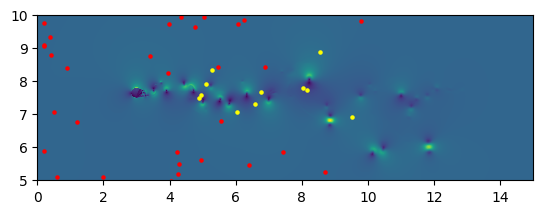

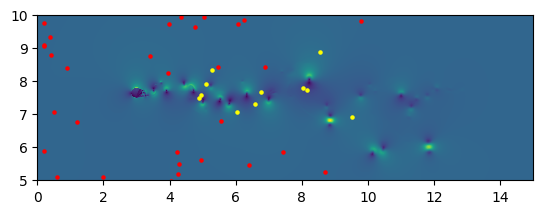

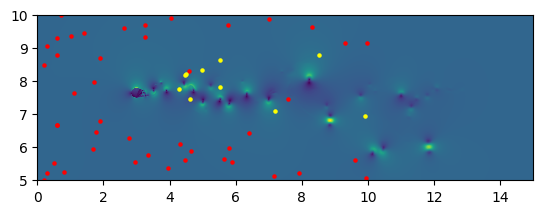

In [13]:
plot_water_velocity_and_organisms(fd, time_step=100)
plot_water_velocity_and_organisms(fd_2, time_step=100)
plot_water_velocity_and_organisms(fd_3, time_step=100)

In [17]:
fd.statistics[0]

,species,pos_x,pos_y,velocity,angle,radius,energy,observed,max_emission,emission fraction,...,pulse sd,pulse size,pulse start,is_emitting,emission_duration,encounter photons,shear photons,photons,is_injected,pos_z
0,Paraphyllina ransoni Russell,NaN,NaN,0.000000,5.792307,0.001830,1.0,False,8.322813,0.1,...,4.0,4.000000e+00,False,False,0,0,0.0,0.0,False,71.933605
1,long pulse 1,24.144490,8.638886,0.003718,4.761688,0.001196,1.0,True,11.747487,0.1,...,1.5,1.500000e+00,False,False,-1,0,0.0,0.0,False,49.925299
2,Bargmannia sp. nov.a,28.422650,5.824580,0.006860,0.090437,0.001117,1.0,True,10.295430,0.1,...,4.0,4.000000e+00,False,False,-1,0,0.0,0.0,False,60.842523
3,Chuniphyes multidentata Lens and van Riemsdijk,0.921668,12.237733,-0.000485,0.729306,0.000930,1.0,True,14.308121,0.1,...,4.0,4.000000e+00,False,False,-1,0,0.0,0.0,False,33.394499
4,Periphylla periphylla PeÂron and Lesueur,NaN,NaN,0.000000,2.044111,0.000905,1.0,False,3.579491,0.1,...,4.0,4.000000e+00,False,False,0,0,0.0,0.0,False,69.359125
5,example pulse 1,NaN,NaN,0.000000,2.442131,0.001358,1.0,False,18.864510,0.1,...,1.5,1.500000e+00,False,False,0,0,0.0,0.0,False,31.748912
6,Paraphyllina ransoni Russell,8.593492,7.326786,0.007335,0.289043,0.001166,1.0,True,29.799694,0.1,...,4.0,4.000000e+00,False,False,-1,0,0.0,0.0,False,62.527943
7,short pulse,7.372986,9.120776,0.000985,0.255907,0.000895,1.0,True,19.523658,0.1,...,0.3,3.000000e-01,False,False,-1,0,0.0,0.0,False,63.132336
8,Chuniphyes multidentata Lens and van Riemsdijk,NaN,NaN,0.000000,2.241547,0.000782,1.0,False,13.201124,0.1,...,4.0,4.000000e+00,False,False,0,0,0.0,0.0,False,25.701879
9,Chuniphyes multidentata Lens and van Riemsdijk,12.268469,3.993355,-0.000369,5.375017,0.001033,1.0,True,17.501237,0.1,...,4.0,4.000000e+00,False,False,-1,0,0.0,0.0,False,54.563841


In [11]:
fd.statistics[-1]

,species,pos_x,pos_y,velocity,angle,radius,energy,observed,max_emission,emission fraction,...,pulse sd,pulse size,pulse start,is_emitting,emission_duration,encounter photons,shear photons,photons,is_injected,pos_z
0,Paraphyllina ransoni Russell,NaN,NaN,0.000000,5.792307,0.001830,1.0,False,8.322813,0.1,...,4.0,4.000000e+00,False,False,0,0,0.0,0.0,False,71.933605
1,long pulse 1,NaN,NaN,0.004780,5.382001,0.001196,1.0,False,11.747487,0.1,...,1.5,1.500000e+00,False,False,-60,0,0.0,0.0,False,49.925299
2,Bargmannia sp. nov.a,NaN,NaN,0.001708,0.687805,0.001117,1.0,False,10.295430,0.1,...,4.0,4.000000e+00,False,False,-17,0,0.0,0.0,False,60.842523
3,Chuniphyes multidentata Lens and van Riemsdijk,NaN,NaN,0.005590,1.582895,0.000930,1.0,False,14.308121,0.1,...,4.0,4.000000e+00,False,False,-298,0,0.0,0.0,False,33.394499
4,Periphylla periphylla PeÂron and Lesueur,NaN,NaN,0.000000,2.044111,0.000905,1.0,False,3.579491,0.1,...,4.0,4.000000e+00,False,False,0,0,0.0,0.0,False,69.359125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,long pulse 1,0.677222,2.628315,0.005618,5.946899,0.001530,1.0,True,16.879501,0.1,...,1.5,1.000000e+10,False,False,-7,0,0.0,0.0,True,71.527048
306,short pulse,0.601152,6.604275,0.003158,3.887659,0.001417,1.0,True,19.631559,0.1,...,0.3,1.000000e+10,False,False,-6,0,0.0,0.0,True,48.423292
307,Apolemia sp. 1,0.488324,3.097399,0.001418,2.886454,0.001340,1.0,True,18.052930,0.1,...,4.0,1.000000e+10,False,False,-5,0,0.0,0.0,True,33.968622
308,long pulse 1,0.195710,3.044816,0.001320,5.403886,0.001350,1.0,True,11.116192,0.1,...,1.5,1.000000e+10,False,False,-2,0,0.0,0.0,True,66.880006


In [ ]:
# fds = []
# for i in tqdm(range(5)):
#     baseconfig = create_config(config_icetray._baseconfig, rs = 42 + i)
#     fd_temp = Fourth_Day(userconfig=baseconfig)
#     fd_temp.sim()
#     fds.append(fd_temp)

  0%|          | 0/5 [00:00<?, ?it/s]

Lower detector!
Middle detector!
Upper detector!


 20%|██        | 1/5 [01:40<06:43, 100.97s/it]

Lower detector!
Middle detector!
Upper detector!


 40%|████      | 2/5 [03:00<04:25, 88.38s/it] 

...

 60%|██████    | 3/5 [04:07<02:36, 78.39s/it]

Lower detector!
Middle detector!
Upper detector!


 80%|████████  | 4/5 [05:07<01:11, 71.39s/it]

Lower detector!
Middle detector!
Upper detector!


100%|██████████| 5/5 [06:10<00:00, 74.09s/it]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import pickle
import glob

In [19]:
files = sorted(glob.glob("all_simulations_movement_True*.pkl"))

#all_simulations_true = []
time_step = 299
emission_positions_true = []

for f in files:
    print("Loading:", f)
    with open(f, "rb") as handle:
        data = pickle.load(handle)
        #all_simulations_true.extend(data)   # extend, not append!
        # Collect all x,y positions where emission occurs at this time step

        for sim in data:
            df_step = sim.statistics[time_step]
            emitting = df_step.loc[df_step['is_emitting'], ['pos_x', 'pos_y']].to_numpy()
            if len(emitting) > 0:
                #print('emission happened')
                emission_positions_true.append(emitting)

# Stack all positions into a single array
if len(emission_positions_true) > 0:
    emission_positions_true = np.vstack(emission_positions_true)
else:
    emission_positions_true = np.empty((0,2))

Loading: all_simulations_movement_True_seed_142.pkl


Loading: all_simulations_movement_True_seed_192.pkl
Loading: all_simulations_movement_True_seed_42.pkl
Loading: all_simulations_movement_True_seed_92.pkl


In [20]:
files = sorted(glob.glob("all_simulations_movement_False_seed_*.pkl"))

#all_simulations_true = []
time_step = 299
emission_positions_false = []

for f in files:
    print("Loading:", f)
    with open(f, "rb") as handle:
        data = pickle.load(handle)
        #all_simulations_true.extend(data)   # extend, not append!
        # Collect all x,y positions where emission occurs at this time step

        for sim in data:
            df_step = sim.statistics[time_step]
            emitting = df_step.loc[df_step['is_emitting'], ['pos_x', 'pos_y']].to_numpy()
            if len(emitting) > 0:
                #print('emission happened')
                emission_positions_false.append(emitting)

# Stack all positions into a single array
if len(emission_positions_false) > 0:
    emission_positions_false = np.vstack(emission_positions_false)
else:
    emission_positions_false = np.empty((0,2))

Loading: all_simulations_movement_False_seed_142.pkl
Loading: all_simulations_movement_False_seed_192.pkl
Loading: all_simulations_movement_False_seed_42.pkl
Loading: all_simulations_movement_False_seed_92.pkl


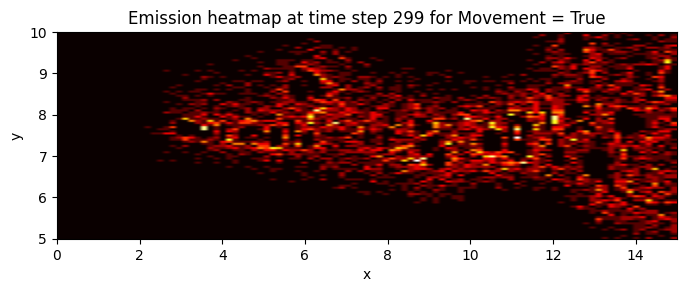

In [ ]:
x_bins = np.linspace(0, 15, 100) 
y_bins = np.linspace(5, 10, 100)

H, xedges, yedges = np.histogram2d(
    emission_positions_true[:,0],
    emission_positions_true[:,1],
    bins=[x_bins, y_bins]
)

H_normalized = H / H.sum()

plt.figure(figsize=(8,4))
plt.imshow(
    H_normalized.T,   
    origin='lower',
    extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
    aspect='equal',
    cmap='hot'
)
#plt.colorbar(label='Normalized emission frequency')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Emission heatmap at time step {time_step} for Movement = True')
plt.show()

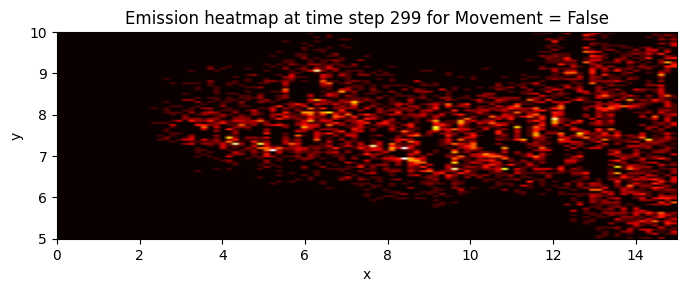

In [ ]:
x_bins = np.linspace(0, 15, 100) 
y_bins = np.linspace(5, 10, 100)

H, xedges, yedges = np.histogram2d(
    emission_positions_false[:,0],
    emission_positions_false[:,1],
    bins=[x_bins, y_bins]
)

H_normalized = H / H.sum()

plt.figure(figsize=(8,4))
plt.imshow(
    H_normalized.T,
    origin='lower',
    extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
    aspect='equal',
    cmap='hot'
)
#plt.colorbar(label='Normalized emission frequency')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Emission heatmap at time step {time_step} for Movement = False')
#plt.set_aspect('equal', adjustable='box')
plt.show()